### 🎯 Project Objective: Predictive Churn Modeling
Goal: To develop a Machine Learning pipeline that identifies customers at risk of leaving the platform, enabling proactive retention strategies.

**Key steps in this notebook:**
- **Population Filtering:** Focusing on users with purchase history.
- **Feature Engineering:** Creating behavioral metrics (Recency, Conversion Rate, etc.).
- **Model Training:** Implementing a Random Forest Classifier.
- **Optimization:** Handling bias by refining feature selection.

#### 🛠️ Loading Refined Dataset (Silver Layer)
Source: 2019-Oct-Refined.parquet

In [ ]:
import pandas as pd
from pathlib import Path

# Only search inside the workspace Silver folder
silver_dir = Path("../data/Silver/")
if not silver_dir.exists():
    raise FileNotFoundError(f"Silver directory not found in workspace (searched from {Path('.').resolve()})")

target_name = "2019-Oct-Refined.parquet"
found = list(silver_dir.rglob(target_name))
if not found:
    raise FileNotFoundError(f"{target_name} not found in Silver folder (searched under {silver_dir.resolve()})")

file_path = found[0]
print(f"Reading parquet from: {file_path}")
df = pd.read_parquet(file_path)

print('Reading Done!')




Reading parquet from: ..\data\Silver\2019-Oct-Refined.parquet


#### 🛒 Population Filtering: Extracting Buyers
In this step, we separate users with at least one 'purchase' event from casual browsers. This ensures our churn model focuses on actual customer retention rather than general website traffic.

In [2]:
buyers_list=df[df['event_type']=='purchase']['user_id'].unique()
df_buyers= df[df['user_id'].isin(buyers_list)].copy()
print(f'Total Number of unique purchaces : {len(df_buyers)}')



Total Number of unique purchaces : 14173245


#### ⏳ Temporal Splitting (Feature vs. Label Windows)
To create a robust churn model, we split the buyer's history into two periods:
1. **Training Window:** Events before Oct 21st (used for feature engineering).
2. **Prediction Window:** Events after Oct 21st (used to define the target variable/churn).

This chronological approach prevents **Data Leakage** and simulates how the model will perform in production.

In [3]:
split_date=pd.Timestamp('2019-10-21')
train_df= df_buyers[df_buyers['event_time']<= split_date]
label_df= df_buyers[df_buyers['event_time']> split_date]

#### 🧩 Feature Engineering: Creating behavioral metrics (Recency, Conversion Rate, etc.).

In [7]:
features= train_df.groupby('user_id').agg(
    total_events=('event_type','count'),
    purchase_count=('event_type', lambda x:(x=='purchase').sum()),
    view_count=('event_type',lambda x:(x=='view').sum()),
    cart_count=('event_type',lambda x:(x=='cart').sum()),
    total_spend=('price','sum'),
    unique_categories=('category_code', 'nunique'),
    last_event_time=('event_time','max')
).reset_index()

features['recency'] = (split_date -features['last_event_time']).dt.days
features['conversion_rate'] = (features['purchase_count'] / features['total_events']).fillna(0)

features.drop(columns=['last_event_time'], inplace=True)

features.head()

,user_id,total_events,purchase_count,view_count,cart_count,total_spend,unique_categories,recency,conversion_rate
0,264649825,23,2,21,0,12161.980469,3,13,0.086957
1,303160429,3,1,2,0,1021.989990,1,7,0.333333
2,340041246,83,4,78,1,15545.570312,10,6,0.048193
3,371877401,142,1,141,0,3112.899902,9,3,0.007042
4,384989212,199,1,198,0,26189.029297,9,2,0.005025


#### 🎯 Target Variable Engineering (Labeling)
We define the **Target Variable (`is_churned`)** based on user activity during the final 10 days of October:
- **Churned (1):** Users who made a purchase before Oct 21st but had NO events after that date.
- **Retained (0):** Users who remained active in the prediction window.

*Note: We use vectorized operations for efficient labeling across large user IDs.*

In [ ]:
# Use set for much faster search speed
active_users_set = set(label_df['user_id'].unique())

# Labeling: Users not found in the 'active' set are marked as churned (1)
features['is_churned'] = (~features['user_id'].isin(active_users_set)).astype(int)

features.head()


,user_id,total_events,purchase_count,view_count,cart_count,total_spend,unique_categories,recency,conversion_rate,is_churned
0,264649825,23,2,21,0,12161.980469,3,13,0.086957,1
1,303160429,3,1,2,0,1021.989990,1,7,0.333333,1
2,340041246,83,4,78,1,15545.570312,10,6,0.048193,1
3,371877401,142,1,141,0,3112.899902,9,3,0.007042,0
4,384989212,199,1,198,0,26189.029297,9,2,0.005025,0


#### 💾 Exporting Gold Dataset & Class Distribution Check
We save the final feature-engineered dataset to the Gold Layer for model training. We also perform a sanity check on the Class Imbalance to understand the churn rate in our population.

In [23]:
# Path for the final ML-ready dataset
feat_file_path = '../data/gold/churn_model_dataset.parquet'

# Save to Gold layer using Parquet for optimized space and speed
features.to_parquet(feat_file_path, index=False)
print(f'✅ Final Dataset for modeling saved at: {feat_file_path}')

# Display churn distribution (Target Variable)
print("\n📊 Target Class Distribution:")
print(features['is_churned'].value_counts(normalize=True).map('{:.2%}'.format))

✅ Final Dataset for modeling saved at: ../data/gold/churn_model_dataset.parquet

📊 Target Class Distribution:
is_churned
0    52.88%
1    47.12%
Name: proportion, dtype: object


#### ⚙️ Model Preprocessing: Feature Selection & Data Splitting
In this stage, we prepare the data for the machine learning algorithm:

Feature Selection: We drop identifiers (user_id) and the target variable (is_churned). As previously analyzed, we also remove total_spend to prevent Model Bias caused by high-priced electronics.

Stratified Splitting: We use a 70/30 split with stratification to ensure the churn distribution is preserved across training and testing sets.

In [24]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load the feature-engineered dataset from Gold layer
feat_file_path = '../data/gold/churn_model_dataset.parquet'
features = pd.read_parquet(feat_file_path)

# Feature Selection: Dropping IDs, Target, and Biased features (total_spend)
X = features.drop(columns=['user_id', 'is_churned', 'total_spend'])
y = features['is_churned']

# Stratified Split: 70% Training, 30% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y # Crucial for handling imbalanced churn classes
)

print(f'✅ Training set size: {len(X_train):,}')
print(f'✅ Testing set size: {len(X_test):,}')
print(f'📊 Features used for training: {list(X.columns)}')


✅ Training set size: 204,779
✅ Testing set size: 87,763
📊 Features used for training: ['total_events', 'purchase_count', 'view_count', 'cart_count', 'unique_categories', 'recency', 'conversion_rate']


#### 🤖 Model Training: Random Forest Classifier
We initialize the Random Forest algorithm, an ensemble method that builds multiple decision trees to improve predictive accuracy.

Hyperparameters: We set n_estimators=100 for a robust ensemble and n_jobs=-1 to enable parallel processing, significantly reducing training time on our large dataset.

Objective: The model learns the complex non-linear relationships between behavioral features (like conversion rate and frequency) and the likelihood of churn.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize Random Forest with optimized settings for high-volume data
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1  # Utilize all available CPU cores
)

# Training the model on the observation window features
rf_model.fit(X_train, y_train)

# Generating predictions for the test set
y_pred = rf_model.predict(X_test)

print("✅ Model training completed.")

✅ Model training completed.


#### 📊 Model Evaluation: Measuring Performance
We evaluate the model's effectiveness using key metrics to ensure it can accurately identify churners:

Accuracy Score: The overall percentage of correct predictions.

Classification Report: Detailed metrics including Precision (avoiding false alarms) and Recall (successfully catching churners).

Focus: For churn prediction, a high Recall for Class 1 is essential to ensure we don't miss at-risk customers.

In [12]:
print("--- Accuracy Score ---")
print(f"{accuracy_score(y_test, y_pred):.2f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Accuracy Score ---
0.71

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.67      0.71     46411
           1       0.67      0.75      0.71     41352

    accuracy                           0.71     87763
   macro avg       0.71      0.71      0.71     87763
weighted avg       0.72      0.71      0.71     87763



#### 🥇 Feature Importance Ranking
We analyze the Gini importance (mean decrease in impurity) of each feature. This ranking validates our Feature Engineering phase and highlights the most discriminative variables in the classification process.

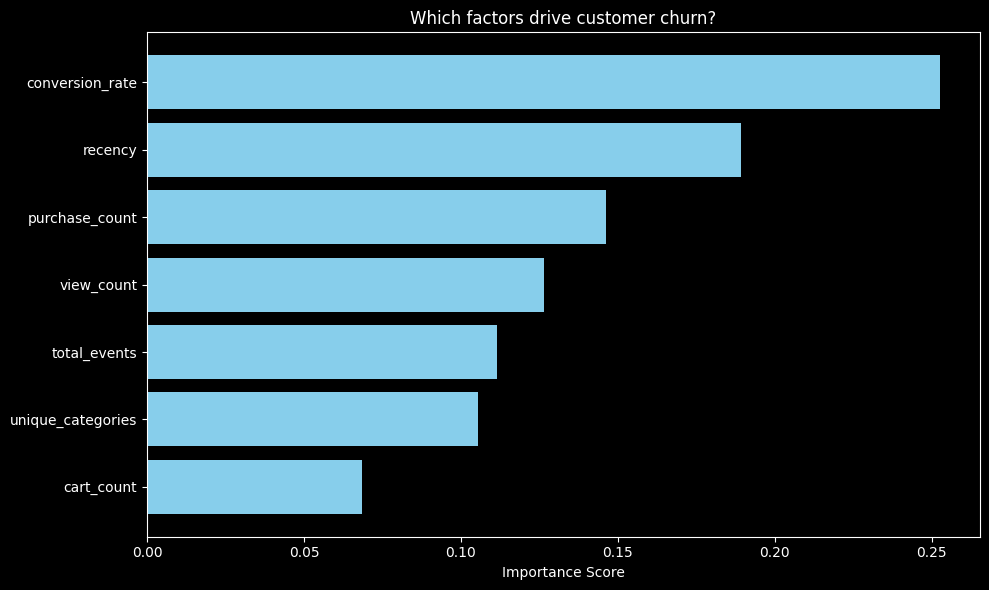

In [ ]:
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from src.Utils import save_plot

# استخراج اهمیت ویژگی‌ها
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# رسم نمودار
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Which factors drive customer churn?')
plt.gca().invert_yaxis()
save_plot('churn_importance_optimized.png', show=True)
#plt.show()

#### 📦 Model Serialization (Pickling)
Exporting the optimized churn prediction model to the models/ directory for future inference on new customer data.

In [11]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(rf_model,'../models/churn_random_forest_v1.pkl')

print('Final model saved successfully.')

Final model saved successfully.
